# Importing Database

In [1]:
# pip install kagglehub (Successfully installed kagglehub-0.3.13)
#!pip install --upgrade kagglehub

import kagglehub

In [2]:
path = kagglehub.dataset_download("mdrazakhan/linear-regression-dataset")

In [3]:
print("Path to dataset files:", path)

Path to dataset files: C:\Users\prati\.cache\kagglehub\datasets\mdrazakhan\linear-regression-dataset\versions\2


# Loading Dataset

In [4]:
import pandas as pd

In [5]:
cars = pd.read_csv(r"C:\Users\prati\.cache\kagglehub\datasets\mdrazakhan\linear-regression-dataset\versions\2\cars.csv")

## Inspecting dataset

In [6]:
cars.head()

,Car,Model,Volume,Weight,CO2
0,Toyoty,Aygo,1000,790,99
1,Mitsubishi,Space Star,1200,1160,95
2,Skoda,Citigo,1000,929,95
3,Fiat,500,900,865,90
4,Mini,Cooper,1500,1140,105


In [7]:
cars.shape

(36, 5)

In [8]:
cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Car     36 non-null     object
 1   Model   36 non-null     object
 2   Volume  36 non-null     int64 
 3   Weight  36 non-null     int64 
 4   CO2     36 non-null     int64 
dtypes: int64(3), object(2)
memory usage: 1.5+ KB


## >Using Multiple LinearRegression 

## Selecting columns and creating new data frame

In [9]:
cars[['Volume','Weight','CO2']]

,Volume,Weight,CO2
0,1000,790,99
1,1200,1160,95
2,1000,929,95
3,900,865,90
4,1500,1140,105
5,1000,929,105
6,1400,1109,90
7,1500,1365,92
8,1500,1112,98
9,1600,1150,99


In [10]:
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'Volume vs CO2')

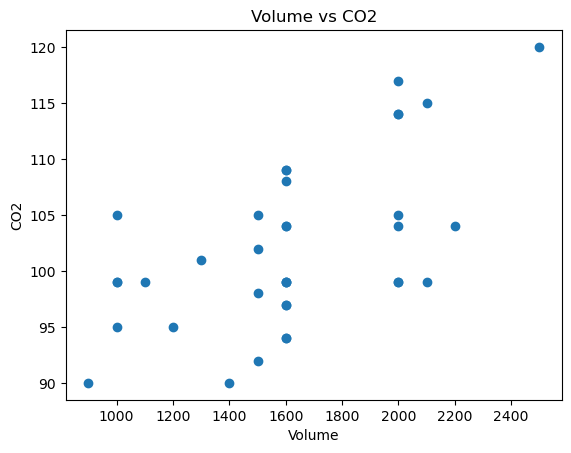

In [11]:
plt.scatter(cars['Volume'], cars['CO2'])
plt.xlabel('Volume')
plt.ylabel('CO2')
plt.title('Volume vs CO2')

Text(0.5, 1.0, 'Weigth vs CO2')

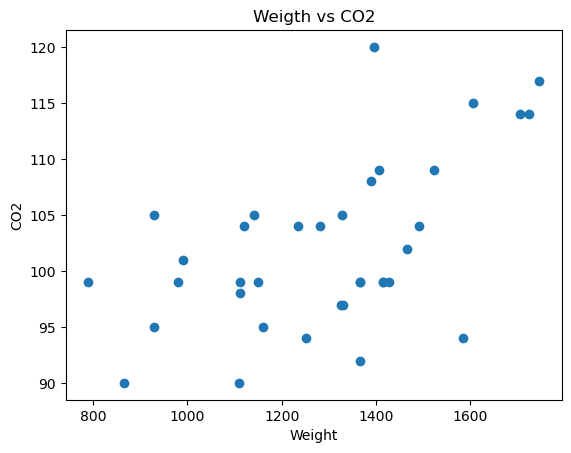

In [12]:
plt.scatter(cars['Weight'], cars['CO2'])
plt.xlabel('Weight')
plt.ylabel('CO2')
plt.title('Weigth vs CO2')

### Grouping by Volume was done to reduce noise and observe average CO2 emissions for each engine size.

In [13]:
cars1 = cars[['Volume','Weight','CO2']].groupby('Volume').mean()

In [14]:
cars1 # You need to reset index or else it will create error

,Weight,CO2
Volume,,
900,865.000000,90.000000
1000,940.000000,99.500000
1100,980.000000,99.000000
1200,1160.000000,95.000000
1300,990.000000,101.000000
1400,1109.000000,90.000000
1500,1270.500000,99.250000
1600,1341.166667,101.083333
2000,1548.142857,107.428571


In [15]:
cars1 =cars1.reset_index()

Text(0.5, 1.0, 'Volume vs CO2')

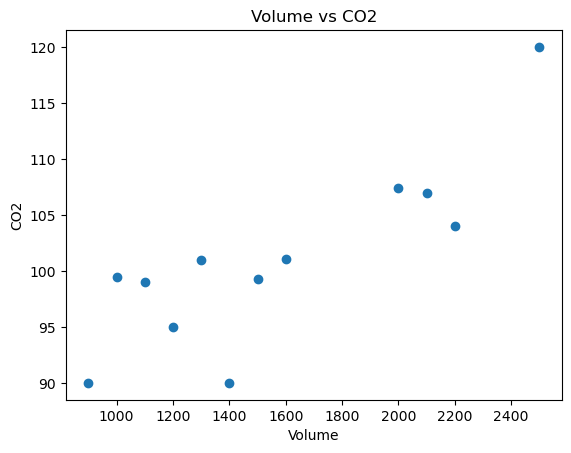

In [16]:
plt.scatter(cars1['Volume'], cars1['CO2'])
plt.xlabel('Volume')
plt.ylabel('CO2')
plt.title('Volume vs CO2')

Text(0.5, 1.0, 'Weigth vs CO2')

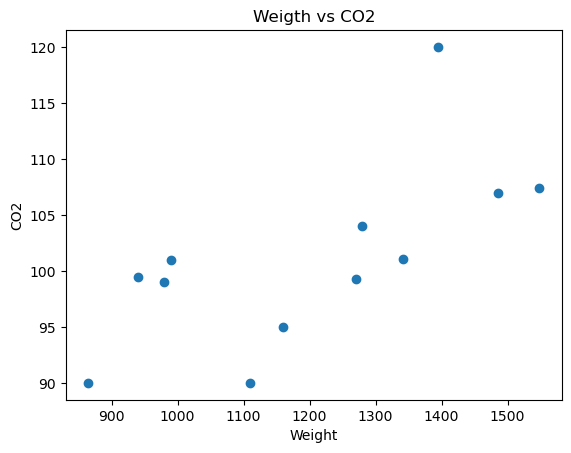

In [17]:
plt.scatter(cars1['Weight'], cars1['CO2'])
plt.xlabel('Weight')
plt.ylabel('CO2')
plt.title('Weigth vs CO2')

## Now seperating X and Y

In [18]:
X = cars1[['Volume','Weight']]

In [19]:
Y = cars1[['CO2']]

In [20]:
X

,Volume,Weight
0,900,865.000000
1,1000,940.000000
2,1100,980.000000
3,1200,1160.000000
4,1300,990.000000
5,1400,1109.000000
6,1500,1270.500000
7,1600,1341.166667
8,2000,1548.142857
9,2100,1485.000000


In [21]:
Y

,CO2
0,90.000000
1,99.500000
2,99.000000
3,95.000000
4,101.000000
5,90.000000
6,99.250000
7,101.083333
8,107.428571
9,107.000000


## Creating train_test_split

In [22]:
from sklearn.model_selection import train_test_split

In [23]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.2, random_state = 42) # Used to keep dataset same for model

In [24]:
X_test

,Volume,Weight
10,2200,1280.0
9,2100,1485.0
0,900,865.0


In [25]:
Y_test

,CO2
10,104.0
9,107.0
0,90.0


## Importing LinearRegression

In [26]:
from sklearn.linear_model import LinearRegression

In [27]:
lr = LinearRegression()

In [28]:
lr.fit(X_train, Y_train)

LinearRegression()

In [29]:
lr.coef_

array([[ 0.02101222, -0.01710075]])

In [30]:
lr.intercept_

array([90.00576406])

## Evaluating Model

In [31]:
from sklearn.metrics import mean_squared_error, r2_score

In [32]:
Y_pred=lr.predict(X_test) # You need to predict Y before you evaluate model

In [33]:
mean_squared_error(Y_test,Y_pred)

42.34032872460858

### Importing Numpy for numeric solution (part of evaluation)

In [34]:
import numpy as np

In [35]:
rmse = np.sqrt(mean_squared_error(Y_test,Y_pred))

In [36]:
rmse

6.506944653568876

In [37]:
rsq = r2_score(Y_test, Y_pred) # Calculating R2 score very useful for evaluation of model

In [38]:
rsq # R2 score closer to 1 better the model

0.22861749287150368

Text(0.5, 1.0, 'Volume vs CO2')

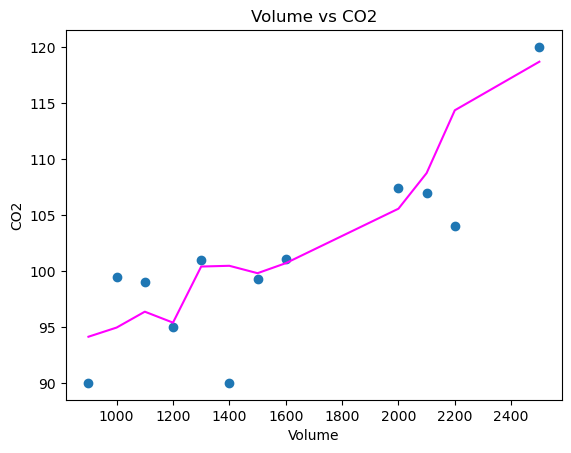

In [39]:
plt.scatter(X['Volume'], Y), plt.plot(X['Volume'], lr.predict(X), color = 'magenta')
plt.xlabel('Volume')
plt.ylabel('CO2')
plt.title('Volume vs CO2')

Text(0.5, 1.0, 'Weight vs CO2')

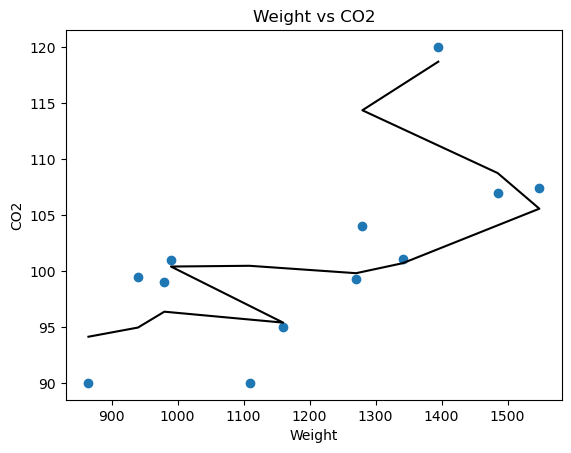

In [40]:
plt.scatter(X['Weight'], Y), plt.plot(X['Weight'], lr.predict(X), color = 'black')
plt.xlabel('Weight')
plt.ylabel('CO2')
plt.title('Weight vs CO2')

# > Multiple Polynomial Regression degree 2

In [41]:
from sklearn.preprocessing import PolynomialFeatures

In [42]:
p2 = PolynomialFeatures(degree = 2)

In [43]:
X_p2 = p2.fit_transform(X)

In [44]:
X_p2

array([[1.00000000e+00, 9.00000000e+02, 8.65000000e+02, 8.10000000e+05,
        7.78500000e+05, 7.48225000e+05],
       [1.00000000e+00, 1.00000000e+03, 9.40000000e+02, 1.00000000e+06,
        9.40000000e+05, 8.83600000e+05],
       [1.00000000e+00, 1.10000000e+03, 9.80000000e+02, 1.21000000e+06,
        1.07800000e+06, 9.60400000e+05],
       [1.00000000e+00, 1.20000000e+03, 1.16000000e+03, 1.44000000e+06,
        1.39200000e+06, 1.34560000e+06],
       [1.00000000e+00, 1.30000000e+03, 9.90000000e+02, 1.69000000e+06,
        1.28700000e+06, 9.80100000e+05],
       [1.00000000e+00, 1.40000000e+03, 1.10900000e+03, 1.96000000e+06,
        1.55260000e+06, 1.22988100e+06],
       [1.00000000e+00, 1.50000000e+03, 1.27050000e+03, 2.25000000e+06,
        1.90575000e+06, 1.61417025e+06],
       [1.00000000e+00, 1.60000000e+03, 1.34116667e+03, 2.56000000e+06,
        2.14586667e+06, 1.79872803e+06],
       [1.00000000e+00, 2.00000000e+03, 1.54814286e+03, 4.00000000e+06,
        3.09628571e+06, 

In [45]:
X_train_p2 = p2.fit_transform(X_train)

In [46]:
X_test_p2 = p2.fit_transform(X_test)

In [47]:
lr2 = LinearRegression()

In [48]:
lr2.fit(X_train_p2, Y_train)

LinearRegression()

In [49]:
Y_pred2 = lr2.predict(X_test_p2)

In [50]:
rmse2 = np.sqrt(mean_squared_error(Y_test, Y_pred2))

In [51]:
rmse2

10.406626783416108

In [52]:
rsq2 = r2_score(Y_test, Y_pred2)

In [53]:
rsq2 # R2 score closer to 1 means better the model

-0.9730383179834439

Text(0.5, 1.0, 'Volume vs CO2')

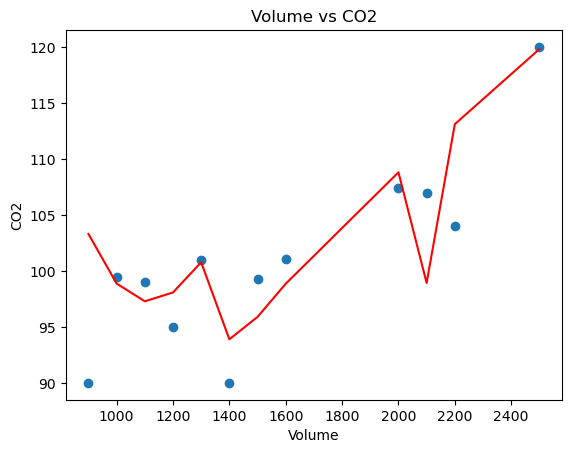

In [54]:
plt.scatter(X['Volume'], Y), plt.plot(X['Volume'], lr2.predict(X_p2), color='red')
plt.xlabel('Volume')
plt.ylabel('CO2')
plt.title('Volume vs CO2')

Text(0.5, 1.0, 'Weight vs CO2')

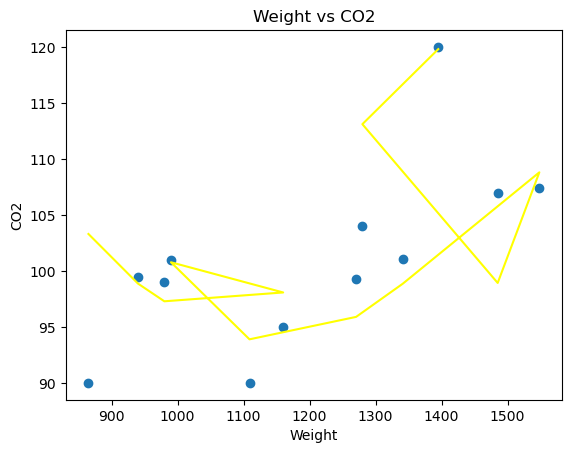

In [55]:
plt.scatter(X['Weight'], Y), plt.plot(X['Weight'], lr2.predict(X_p2), color='yellow')
plt.xlabel('Weight')
plt.ylabel('CO2')
plt.title('Weight vs CO2')

### R2 score of Multiple Polynomial Regression is less than Multiple Linear Regression

### Polynomial performed worse than linear Regression